In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
df = sns.load_dataset('titanic')

In [ ]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [ ]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (891, 15)


In [ ]:
print("Datataset info:")
df.info()

Datataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [ ]:
print("Descriptive Statistics for categorical columns:")
print(df.describe(include=['object','category']))

Descriptive Statistics for categorical columns:
         sex embarked  class  who deck  embark_town alive
count    891      889    891  891  203          889   891
unique     2        3      3    3    7            3     2
top     male        S  Third  man    C  Southampton    no
freq     577      644    491  537   59          644   549


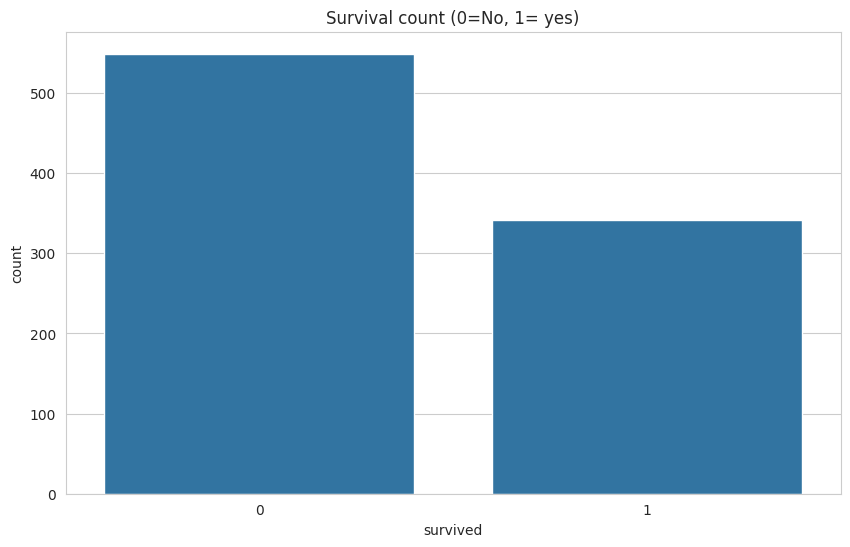

In [ ]:
sns.countplot(x='survived',data=df)
plt.title('Survival count (0=No, 1= yes)')
plt.show()

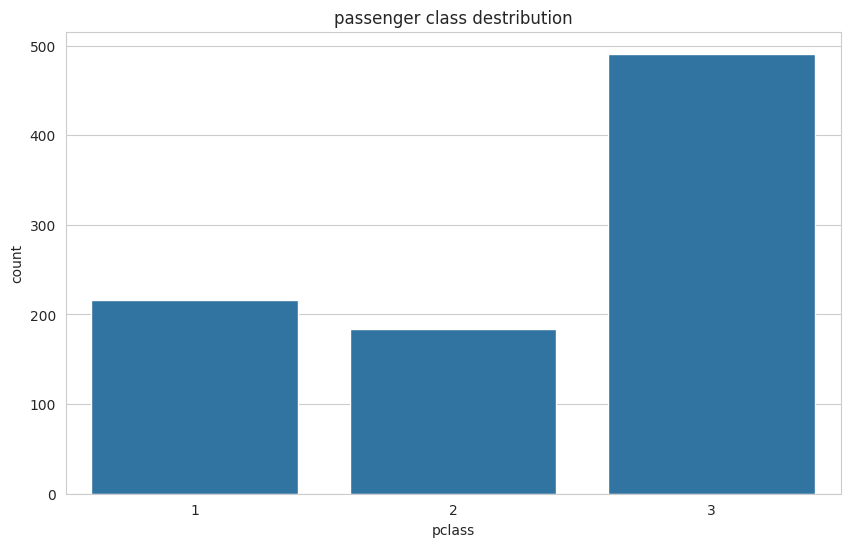

In [ ]:
sns.countplot(x='pclass',data=df)
plt.title('passenger class destribution')
plt.show()


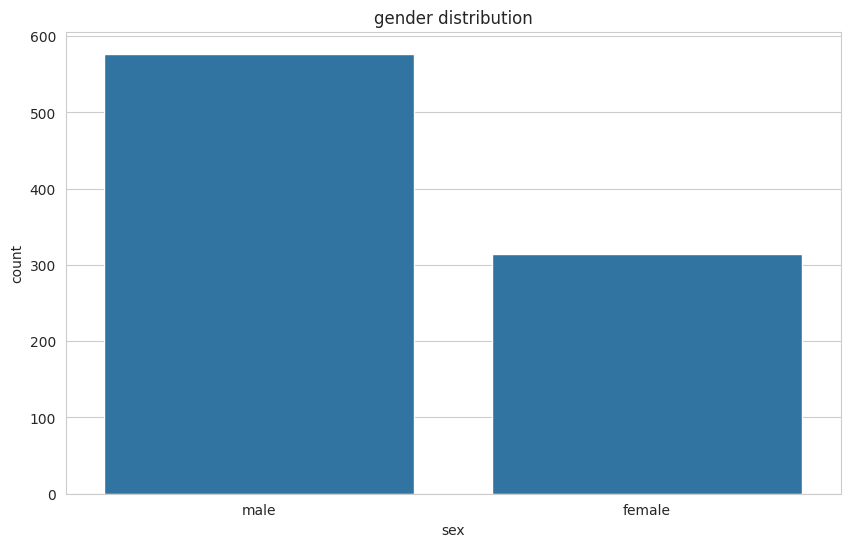

In [ ]:
sns.countplot(x='sex',data=df)
plt.title('gender distribution')
plt.show()

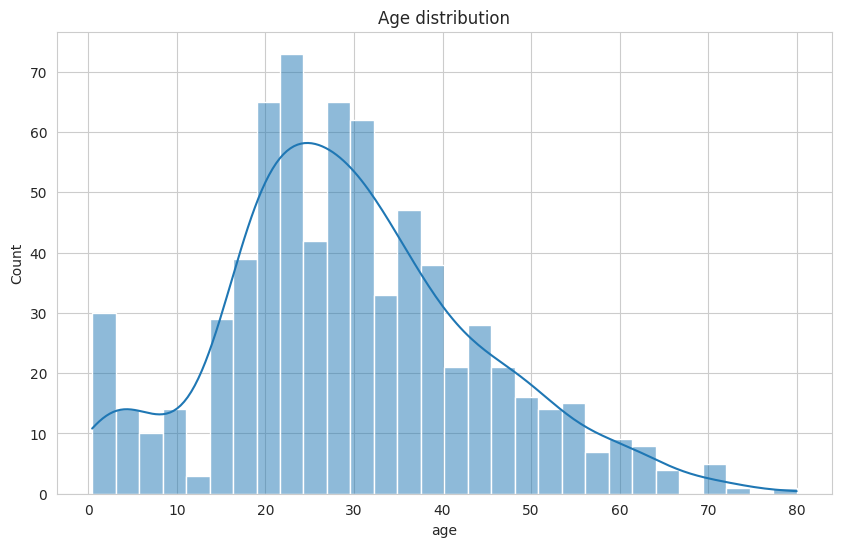

In [ ]:
sns.histplot(df['age'].dropna(),bins=30,kde=True)
plt.title('Age distribution')
plt.show()

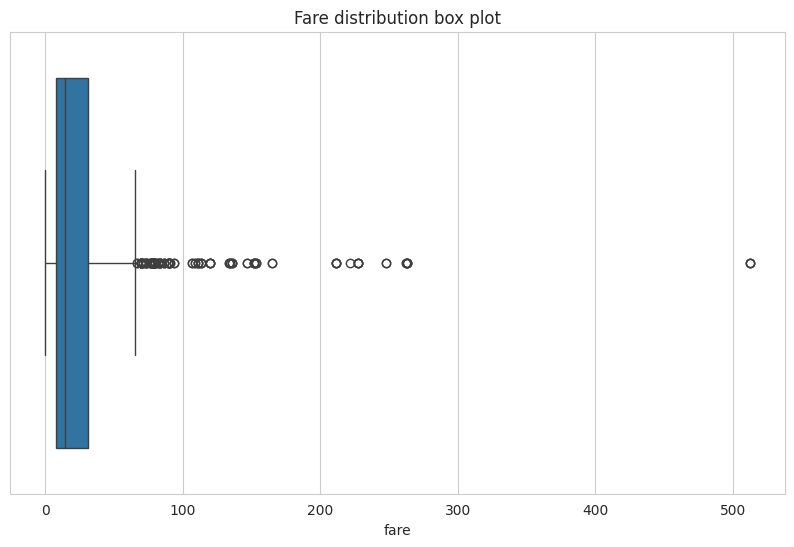

In [ ]:
sns.boxplot(x=df['fare'])
plt.title('Fare distribution box plot')
plt.show()

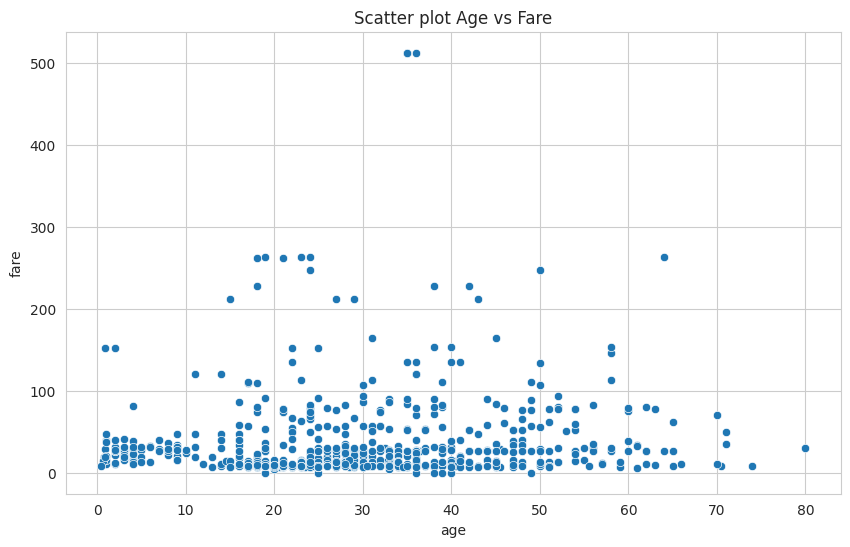

In [ ]:
sns.scatterplot(x='age',y='fare',data=df)
plt.title('Scatter plot Age vs Fare')
plt.show()

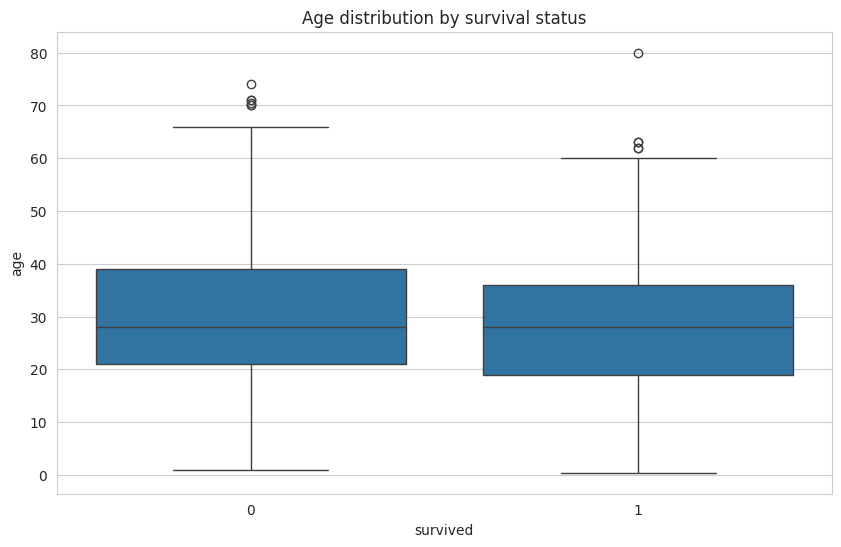

In [ ]:
sns.boxplot(x='survived',y='age',data=df)
plt.title('Age distribution by survival status')
plt.show()

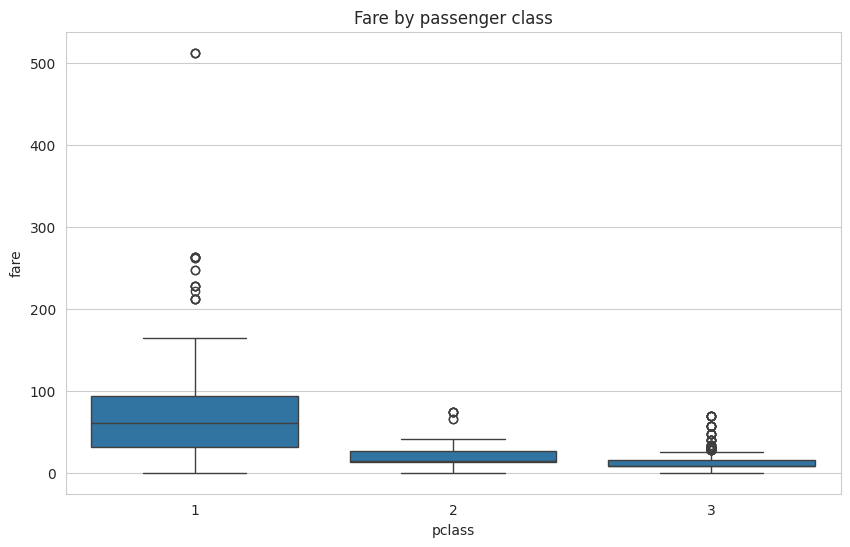

In [ ]:
sns.boxplot(x='pclass',y='fare',data=df)
plt.title('Fare by passenger class')
plt.show()

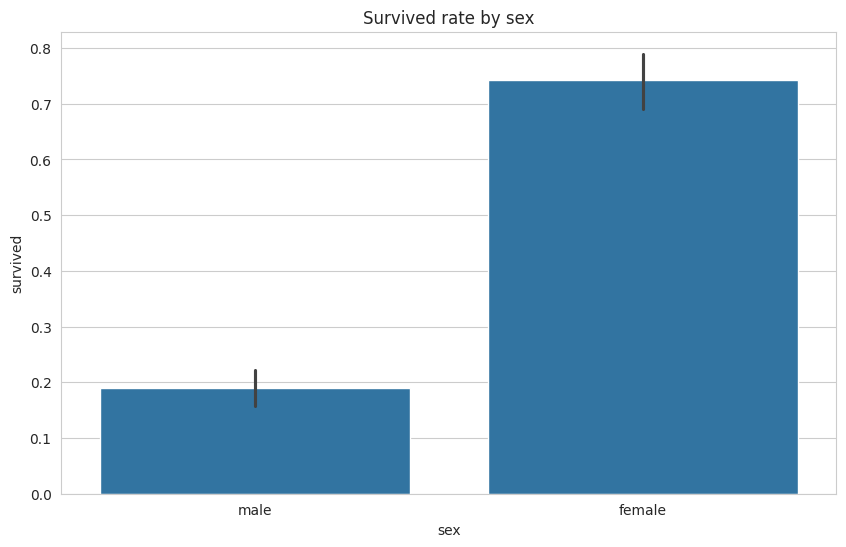

In [ ]:
sns.barplot(x='sex',y='survived',data=df)
plt.title('Survived rate by sex')
plt.show()

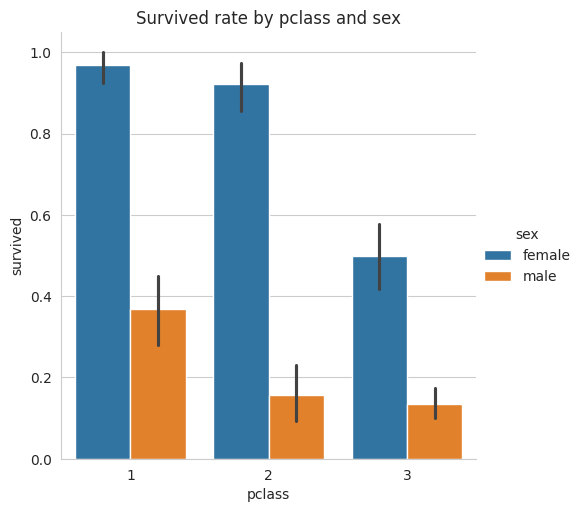

In [ ]:
sns.catplot(x='pclass',y='survived',hue='sex',data=df,kind='bar')
plt.title('Survived rate by pclass and sex')
plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

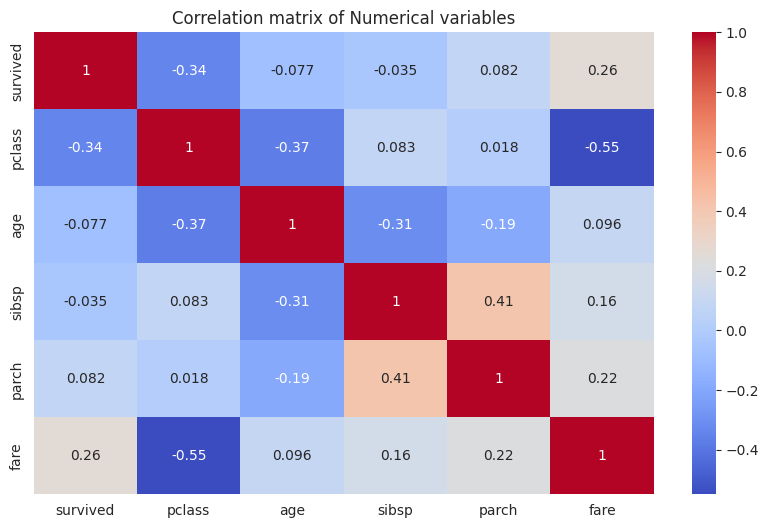

In [ ]:
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation matrix of Numerical variables')
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Sample DataFrame with a categorical column
data = {'Color': ['Red', 'Green', 'Blue', 'Red', 'Green'],
        'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small']}
df = pd.DataFrame(data)

# Initialize the LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to the 'Color' column
df['Color_Encoded'] = le.fit_transform(df['Color'])

# Display the updated DataFrame
print(df)

# To see the mapping of original categories to encoded values
print("\nMapping of 'Color' categories:")
for i, category in enumerate(le.classes_):
    print(f"{category}: {i}")

   Color    Size  Color_Encoded
0    Red   Small              2
1  Green  Medium              1
2   Blue   Large              0
3    Red  Medium              2
4  Green   Small              1

Mapping of 'Color' categories:
Blue: 0
Green: 1
Red: 2


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(categorical_cols))

le = LabelEncoder()

for col in categorical_cols:
    df[col + "_encoded"] = le.fit_transform(df[col].astype(str))
    print(f"\nMapping for column '{col}':")
    for i, category in enumerate(le.classes_):
        print(f"{category}: {i}")

# Display first few rows
print("\nEncoded DataFrame (head):")
print(df.head())


Categorical Columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']

Mapping for column 'sex':
female: 0
male: 1

Mapping for column 'embarked':
C: 0
Q: 1
S: 2
nan: 3

Mapping for column 'class':
First: 0
Second: 1
Third: 2

Mapping for column 'who':
child: 0
man: 1
woman: 2

Mapping for column 'deck':
A: 0
B: 1
C: 2
D: 3
E: 4
F: 5
G: 6
nan: 7

Mapping for column 'embark_town':
Cherbourg: 0
Queenstown: 1
Southampton: 2
nan: 3

Mapping for column 'alive':
no: 0
yes: 1

Encoded DataFrame (head):
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  ...  embark_t

Categorical Columns: ['sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive']

Mapping for column 'sex':
female: 0
male: 1

Mapping for column 'embarked':
C: 0
Q: 1
S: 2
nan: 3

Mapping for column 'class':
First: 0
Second: 1
Third: 2

Mapping for column 'who':
child: 0
man: 1
woman: 2

Mapping for column 'deck':
A: 0
B: 1
C: 2
D: 3
E: 4
F: 5
G: 6
nan: 7

Mapping for column 'embark_town':
Cherbourg: 0
Queenstown: 1
Southampton: 2
nan: 3

Mapping for column 'alive':
no: 0
yes: 1

Encoded DataFrame (head):
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  ...  embark_t

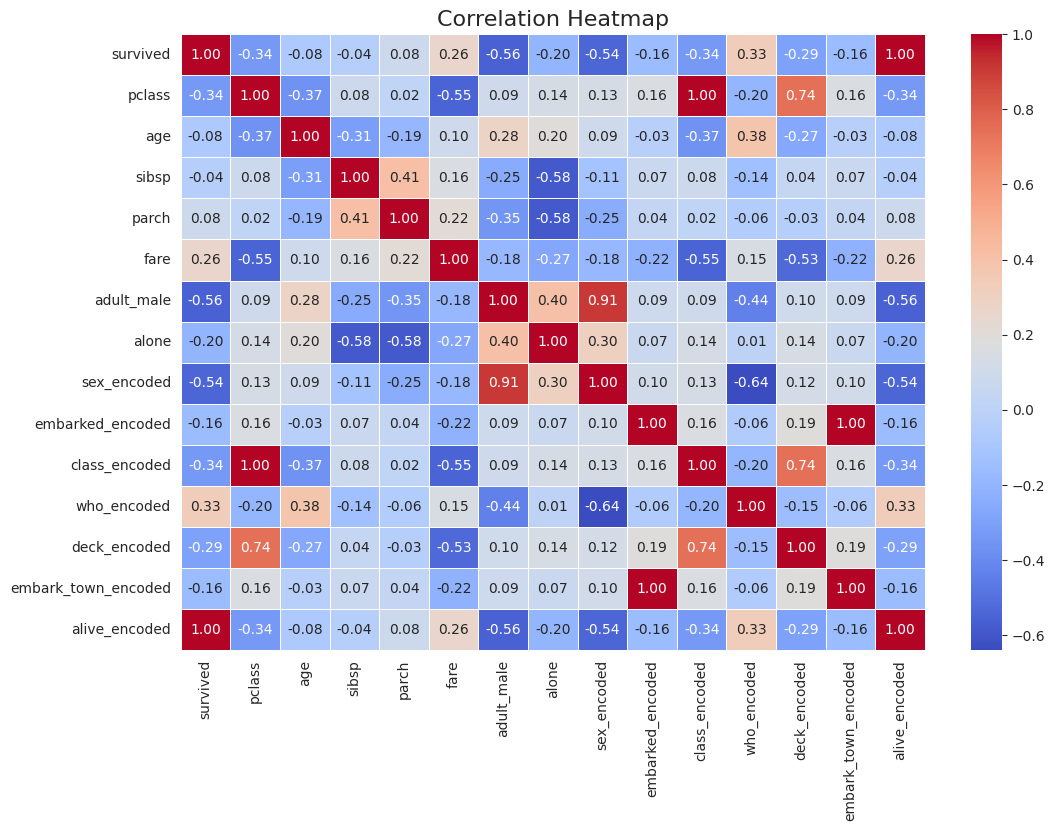


Correlation with Survived column:
survived               1.000000
alive_encoded          1.000000
who_encoded            0.325753
fare                   0.257307
parch                  0.081629
sibsp                 -0.035322
age                   -0.077221
embarked_encoded      -0.163517
embark_town_encoded   -0.163517
alone                 -0.203367
deck_encoded          -0.294804
pclass                -0.338481
class_encoded         -0.338481
sex_encoded           -0.543351
adult_male            -0.557080
Name: survived, dtype: float64


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", list(categorical_cols))

le = LabelEncoder()

# Encode all categorical columns
for col in categorical_cols:
    df[col + "_encoded"] = le.fit_transform(df[col].astype(str))
    print(f"\nMapping for column '{col}':")
    for i, category in enumerate(le.classes_):
        print(f"{category}: {i}")

# Display updated DataFrame
print("\nEncoded DataFrame (head):")
print(df.head())

# ---- Correlation Matrix ----
correlation_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(correlation_matrix)

# ---- Heatmap ----
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

# ---- Correlation with Target ----
print("\nCorrelation with Survived column:")
print(correlation_matrix['survived'].sort_values(ascending=False))


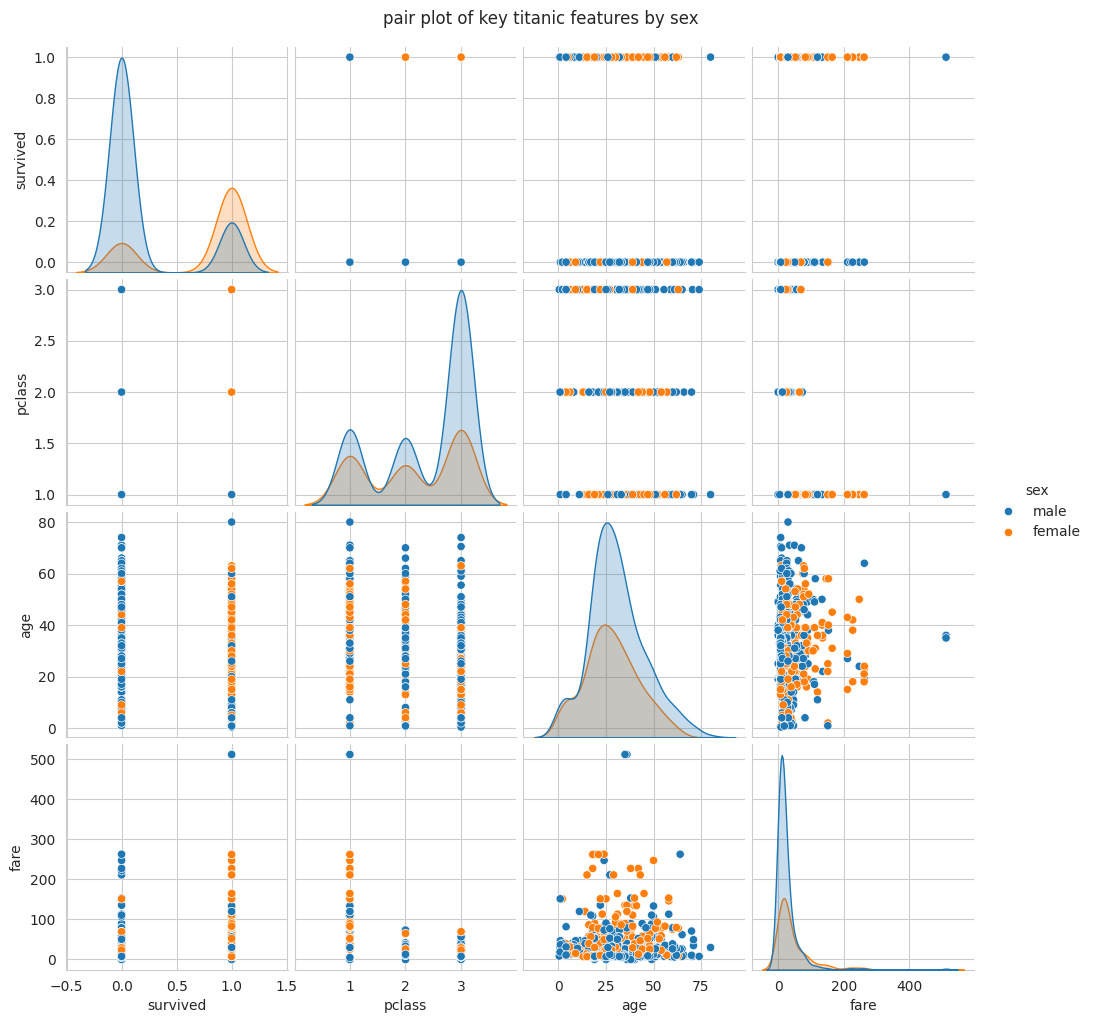

In [ ]:
cols_for_pairplot = ['survived','pclass','age','fare','sex']
sns.pairplot(df[cols_for_pairplot],hue='sex', diag_kind='kde')
plt.suptitle('pair plot of key titanic features by sex', y=1.02)
plt.show()

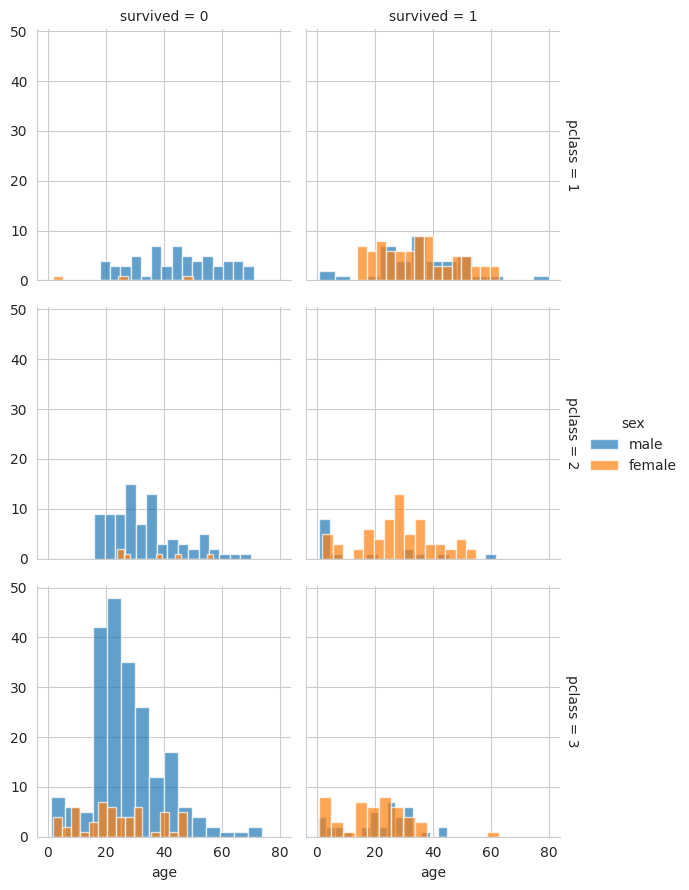

In [ ]:
g = sns.FacetGrid(df,col='survived', row='pclass', hue='sex',margin_titles=True)
g.map(plt.hist,'age',bins=15, alpha=0.7)
g.add_legend()
plt.show()